# Inferring function-function edges (Tier 0)

This notebook demonstrates **Tier 0** edge inference from `docs/notes/edge_inference_notes.md`: score candidate function → function edges using the correlation between per-node **activation magnitudes at layer n−1** and **gradient magnitudes at layer n**:

$$\text{score}(i \to j) = \mathrm{agg}_n\, \mathrm{corr}_b\big(\|z_i^{n-1}\|,\; \|\nabla_{z_j^n}\mathcal{L}\|\big)$$

This matches how GSNN propagates information: activations flow forward $n{-}1 \to n$, gradients flow backward $n \to n{-}1$.

We train a GSNN on a **partial graph** (with held-out function-function edges), then use `MagnitudeEdgeInferer` to recover the missing edges post-hoc. The ground-truth graph uses the **converging-tier DAG** from the Tier 0 plan (3 inputs → 6 function nodes → 3 outputs), scaled up to **12 inputs → 24 function nodes → 12 outputs**, with **16 held-out** function-function edges removed for `G_partial`. No changes to the GSNN model are required.

In [11]:
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
import torch

from gsnn.models.GSNN import GSNN
from gsnn.simulate.nx2pyg import nx2pyg

from gsnn.simulate.simulate import simulate
from gsnn.optim.MagnitudeEdgeInferer import MagnitudeEdgeInferer

from sklearn.metrics import r2_score, roc_auc_score, roc_curve

torch.manual_seed(0)
np.random.seed(0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Build ground-truth graph G*

Same **converging-tier DAG** as the Tier 0 plan, scaled 4×:

| Tier | Plan (small) | This notebook |
|------|--------------|---------------|
| inputs → tier A | 3 → `f0…f2` | 12 → `f0…f11` |
| tier A → tier B | overlapping pairs → `f3,f4` | → `f12…f22` |
| tier B → tier C | `f3,f4 → f5` | `f12…f22 → f23` |
| function → output | `f3→o0, f4→o1, f5→o2` | each tier-B node + sink → `o0…o11` |

At plan scale (`n=3`): `f0→f3`, `f1→f3`, `f1→f4`, `f2→f4`, `f3→f5`, `f4→f5`. Each tier-B node `f_{n+k}` receives from `f_k` and `f_{k+1}`.

**Held-out** edges (16 total) are chosen at the same structural roles, scaled up:
- **10** tier-A → tier-B “left merge” edges `(f_k, f_{n+k})` for `k = 1, …, n−2` (includes the plan’s `f1→f4` at `n=3`)
- **6** tier-B → sink edges on every other merge node (includes the plan’s `f3→f5` at `n=3`)

These are removed when building `G_partial`; the inferrer should rank them above random non-edges.

Tier-A width: 12
inputs: 12 | functions: 24 | outputs: 12
Function-function edges: 33
Held-out edges: 16 | kept in G_partial: 17
Is DAG: True


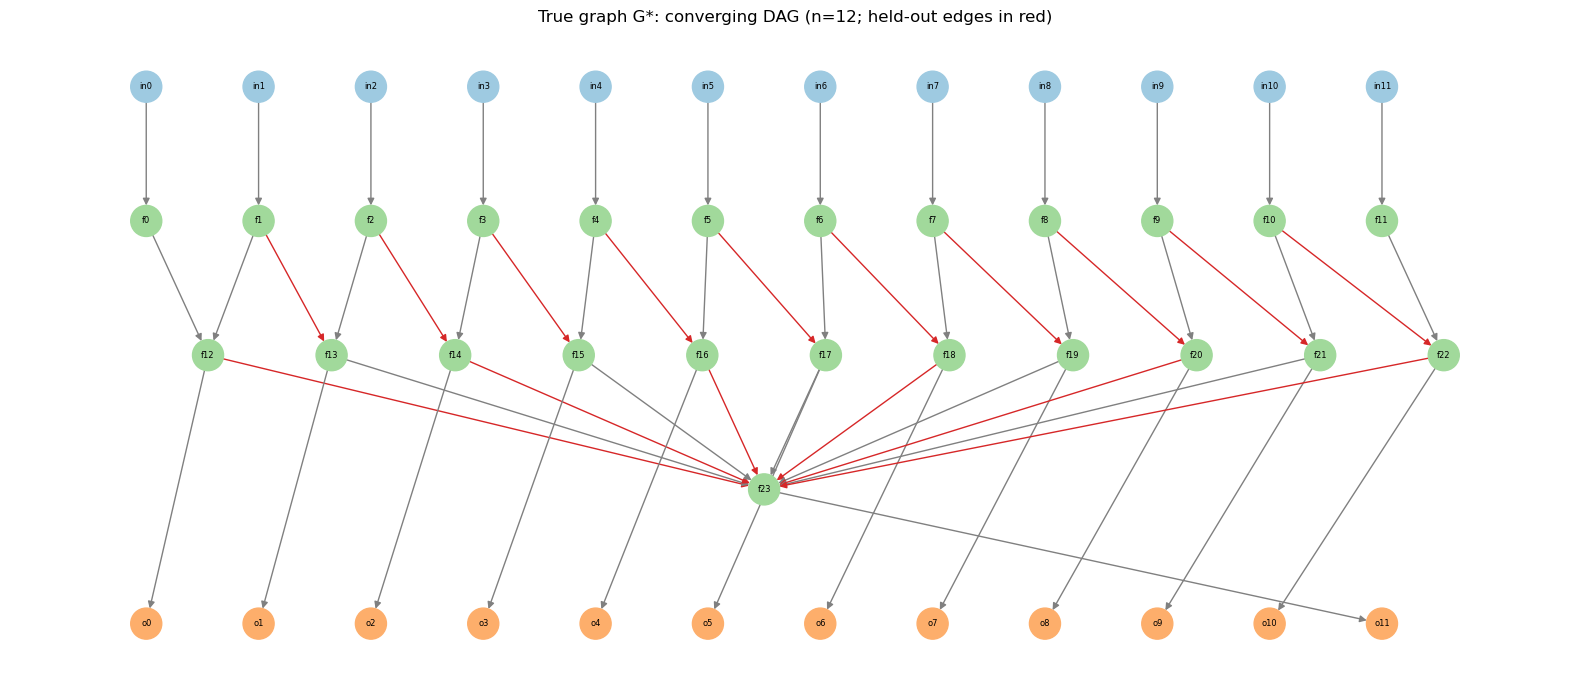

In [12]:
def build_convergence_graph(n_tier_a=6):
    """Converging-tier DAG from the Tier 0 plan, parameterized by tier-A width.

    Structure (n_tier_a=3 matches the plan):
      in_k -> f_k
      f_k, f_{k+1} -> f_{n + k}   for k = 0 .. n_tier_a-2
      all tier-B -> f_sink
      f_{n+k} -> o_k, f_sink -> o_{n_tier_a-1}
    """
    n = n_tier_a
    G = nx.DiGraph()
    func_func_edges_TRUE = []

    input_nodes = [f'in{i}' for i in range(n)]
    tier_a = [f'f{i}' for i in range(n)]
    tier_b = [f'f{n + k}' for k in range(n - 1)]
    tier_c = [f'f{2 * n - 1}']
    function_nodes = tier_a + tier_b + tier_c
    output_nodes = [f'o{k}' for k in range(n)]

    for i, u in enumerate(input_nodes):
        G.add_edge(u, tier_a[i])

    for k in range(n - 1):
        b = tier_b[k]
        for parent in (tier_a[k], tier_a[k + 1]):
            e = (parent, b)
            G.add_edge(*e)
            func_func_edges_TRUE.append(e)

    sink = tier_c[0]
    for b in tier_b:
        e = (b, sink)
        G.add_edge(*e)
        func_func_edges_TRUE.append(e)

    for k, b in enumerate(tier_b):
        G.add_edge(b, output_nodes[k])
    G.add_edge(sink, output_nodes[n - 1])

    # Layered layout for visualization
    pos = {}
    x_spread = max(n - 1, 1)
    for i, u in enumerate(input_nodes):
        pos[u] = (i * 2 * x_spread / max(n - 1, 1) - x_spread, 4.0)
    for i, f in enumerate(tier_a):
        pos[f] = (i * 2 * x_spread / max(n - 1, 1) - x_spread, 3.0)
    for k, f in enumerate(tier_b):
        pos[f] = ((k + 0.5) * 2 * x_spread / max(n - 2, 1) - x_spread, 2.0)
    pos[sink] = (0.0, 1.0)
    for k, o in enumerate(output_nodes):
        pos[o] = (k * 2 * x_spread / max(n - 1, 1) - x_spread, 0.0)

    return G, pos, input_nodes, function_nodes, output_nodes, func_func_edges_TRUE


def default_held_out_edges(n_tier_a, b2sink_stride=2):
    """Held-out ff edges at scaled plan analogues.

    A→B: (f_k, f_{n+k}) for k=1..n-2 — left parent of each merge (f1→f4 at n=3).
    B→sink: (f_{n+k}, f_{2n-1}) for k=0, stride, 2*stride, ... (f3→f5 at n=3).
    """
    n = n_tier_a
    sink = f'f{2 * n - 1}'
    held = [(f'f{k}', f'f{n + k}') for k in range(1, n - 1)]
    held += [(f'f{n + k}', sink) for k in range(0, n - 1, b2sink_stride)]
    return held


N_TIER_A = 12
G, pos, input_nodes, function_nodes, output_nodes, func_func_edges_TRUE = build_convergence_graph(
    n_tier_a=N_TIER_A,
)
N_FUNC = len(function_nodes)

HELD_OUT_EDGES = default_held_out_edges(N_TIER_A, b2sink_stride=2)
held_out_set = set(HELD_OUT_EDGES)
kept_ff_set = set(func_func_edges_TRUE) - held_out_set

assert all(G.has_edge(*e) for e in HELD_OUT_EDGES)
assert len(held_out_set & kept_ff_set) == 0

print(f'Tier-A width: {N_TIER_A}')
print(f'inputs: {len(input_nodes)} | functions: {N_FUNC} | outputs: {len(output_nodes)}')
print(f'Function-function edges: {len(func_func_edges_TRUE)}')
print(f'Held-out edges: {len(HELD_OUT_EDGES)} | kept in G_partial: {len(kept_ff_set)}')
print(f'Is DAG: {nx.is_directed_acyclic_graph(G)}')

node_color = []
for n in G.nodes:
    if n in input_nodes:
        node_color.append('#9ecae1')
    elif n in output_nodes:
        node_color.append('#fdae6b')
    else:
        node_color.append('#a1d99b')

edge_colors = ['C3' if e in held_out_set else 'gray' for e in G.edges]

fig, ax = plt.subplots(figsize=(16, 7))
nx.draw_networkx(
    G, pos, ax=ax, with_labels=True, node_color=node_color, node_size=500,
    font_size=6, arrowsize=10, edge_color=edge_colors,
)
ax.set_title(f'True graph G*: converging DAG (n={N_TIER_A}; held-out edges in red)')
ax.set_axis_off()
plt.tight_layout()
plt.show()

## Simulate data

Use the default linear-Gaussian generative process from `simulate` (as in the Tier 0 plan) so every edge carries signal.

In [ ]:
N_TRAIN = 2000
N_TEST = 500

x_train, x_test, y_train, y_test = simulate(
    G,
    n_train=N_TRAIN,
    n_test=N_TEST,
    input_nodes=input_nodes,
    output_nodes=output_nodes,
    noise_scale=0.15,
    special_functions=None,
)

x_train = torch.tensor(x_train, dtype=torch.float32).to(device)
x_test = torch.tensor(x_test, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

y_mu = y_train.mean(0)
y_std = y_train.std(0)
y_train = (y_train - y_mu) / (y_std + 1e-8)
y_test = (y_test - y_mu) / (y_std + 1e-8)

print('train:', x_train.shape, y_train.shape)
print('test:', x_test.shape, y_test.shape)

## Build partial graph G_partial

Remove the designated held-out function-function edges. The model trains on the remaining graph; we try to recover those edges post-hoc.

In [38]:
held_out_edges = HELD_OUT_EDGES
held_out_set = set(held_out_edges)

kept_edges = [e for e in func_func_edges_TRUE if e not in held_out_set]
true_ff_set = set(func_func_edges_TRUE)

G_partial = G.copy()
G_partial.remove_edges_from(held_out_edges)
data = nx2pyg(G_partial, input_nodes, function_nodes, output_nodes)

n_non_edges = N_FUNC * (N_FUNC - 1) - len(true_ff_set)

print(f'Held-out function-function edges: {len(held_out_edges)}')
print(f'Kept function-function edges: {len(kept_edges)}')
print(f'Non-edges (true negatives): {n_non_edges}')
print(f'G_partial edges: {G_partial.number_of_edges()}')
print('Held-out:', held_out_edges)

Held-out function-function edges: 16
Kept function-function edges: 17
Non-edges (true negatives): 519
G_partial edges: 41
Held-out: [('f1', 'f13'), ('f2', 'f14'), ('f3', 'f15'), ('f4', 'f16'), ('f5', 'f17'), ('f6', 'f18'), ('f7', 'f19'), ('f8', 'f20'), ('f9', 'f21'), ('f10', 'f22'), ('f12', 'f23'), ('f14', 'f23'), ('f16', 'f23'), ('f18', 'f23'), ('f20', 'f23'), ('f22', 'f23')]


## Train GSNN on G_partial

In [39]:
BATCH_SIZE = 64

model_kwargs = {
    'channels': 8,
    'layers': 6,
    'share_layers': False,
    'bias': True,
    'add_function_self_edges': True,
    'norm': 'groupbatch',
    'dropout': 0.,
    'nonlin': torch.nn.ELU,
    'node_mlp': False,
    'checkpoint': False,
}

model = GSNN(
    data.edge_index_dict,
    data.node_names_dict,
    **model_kwargs,
).to(device)

print('n params', sum(p.numel() for p in model.parameters()))

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,  # fixed batch size for GSNN batch-param cache
)

optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0)
crit = torch.nn.MSELoss()

n_epochs = 30
for epoch in range(n_epochs):
    epoch_losses = []
    for x_batch, y_batch in train_loader:
        optim.zero_grad()
        yhat = model(x_batch)
        loss = crit(yhat, y_batch)
        loss.backward()
        optim.step()
        epoch_losses.append(loss.item())

    if epoch == 0 or (epoch + 1) % 5 == 0 or epoch == n_epochs - 1:
        print(f'epoch {epoch + 1:2d}/{n_epochs} | train loss: {np.mean(epoch_losses):.4f}')

model.eval()
with torch.inference_mode():
    yhat_test = model(x_test)
loss_test = crit(y_test, yhat_test)
r2_test = r2_score(y_test.detach().cpu().numpy(), yhat_test.detach().cpu().numpy())
print(f'test loss: {loss_test.item():.4f} | test r2: {r2_test:.3f}')

n params 6924
epoch  1/30 | train loss: 0.6953
epoch  5/30 | train loss: 0.4929
epoch 10/30 | train loss: 0.4903
epoch 15/30 | train loss: 0.4866
epoch 20/30 | train loss: 0.4859
epoch 25/30 | train loss: 0.4857
epoch 30/30 | train loss: 0.4854
test loss: 0.4801 | test r2: 0.516


## Run MagnitudeEdgeInferer

Post-hoc pass over the training data: forward + backward per batch, accumulate streaming correlation statistics.

In [40]:
MEI = MagnitudeEdgeInferer(model, data, reduction='l1')

# Edge inferrer runs forward+backward per batch; reuse the same fixed-size loader.
infer_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(x_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=True,
)

n_samples = MEI.fit(infer_loader, crit=crit, device=device, verbose=True)
res = MEI.evaluate(layer_agg='max')

print(f'Processed {n_samples} samples')
res.head(10)

[batch 31/31] n=1984
Processed 1984 samples


,src_func,dst_func,src_idx,dst_idx,corr,has_edge,corr_a0_g1,corr_a1_g2,corr_a2_g3,corr_a3_g4,corr_a4_g5,p_value,q_value
0,f2,f14,2,14,0.895113,False,0.895113,0.853276,0.779297,0.788583,0.848483,0.0,0.0
1,f6,f18,6,18,0.886441,False,0.874846,0.886441,0.805949,0.798208,0.742110,0.0,0.0
2,f15,f16,15,16,0.879697,False,NaN,0.600171,0.819732,0.879697,0.863181,0.0,0.0
3,f4,f16,4,16,0.876376,False,0.876376,0.787496,0.855820,0.811545,0.868536,0.0,0.0
4,f8,f20,8,20,0.870422,False,0.870422,0.807645,0.820510,0.784994,0.771802,0.0,0.0
5,f13,f14,13,14,0.861188,False,NaN,0.861188,0.744196,0.676358,0.722777,0.0,0.0
6,f20,f21,20,21,0.859313,False,NaN,0.420173,0.695480,0.859313,0.760776,0.0,0.0
7,f3,f15,3,15,0.853414,False,0.834993,0.853414,0.721508,0.778630,0.762166,0.0,0.0
8,f17,f18,17,18,0.852540,False,0.000772,0.784241,0.788614,0.852540,0.764563,0.0,0.0
9,f10,f22,10,22,0.850839,False,0.850839,0.825376,0.835415,0.748628,0.709853,0.0,0.0


In [41]:
kept_set = set(kept_edges)

def edge_category(row):
    pair = (row['src_func'], row['dst_func'])
    if pair in held_out_set:
        return 'held_out'
    if pair in kept_set:
        return 'in_graph'
    return 'non_edge'

res = res.assign(edge_category=res.apply(edge_category, axis=1))

print('Top 10 scored pairs:')
print(res[['src_func', 'dst_func', 'corr', 'edge_category', 'has_edge', 'q_value']].head(10).to_string())

print('\nCategory summary:')
print(res.groupby('edge_category')['corr'].agg(['count', 'mean', 'median', 'std']).to_string())

print('\nPrecision / recall in top-k ranked pairs:')
for k in [10, 25, 50, 100]:
    if k > len(res):
        continue
    topk = res.head(k)
    prec = (topk['edge_category'] == 'held_out').mean()
    recall = (topk['edge_category'] == 'held_out').sum() / len(held_out_edges)
    print(f'  top-{k:3d}: precision={prec:.4f}, recall={recall:.4f}')

Top 10 scored pairs:
  src_func dst_func      corr edge_category  has_edge  q_value
0       f2      f14  0.895113      held_out     False      0.0
1       f6      f18  0.886441      held_out     False      0.0
2      f15      f16  0.879697      non_edge     False      0.0
3       f4      f16  0.876376      held_out     False      0.0
4       f8      f20  0.870422      held_out     False      0.0
5      f13      f14  0.861188      non_edge     False      0.0
6      f20      f21  0.859313      non_edge     False      0.0
7       f3      f15  0.853414      held_out     False      0.0
8      f17      f18  0.852540      non_edge     False      0.0
9      f10      f22  0.850839      held_out     False      0.0

Category summary:
               count      mean    median       std
edge_category                                     
held_out          16  0.576020  0.822944  0.367172
in_graph          17 -0.136474 -0.167437  0.097528
non_edge         519  0.045526 -0.010472  0.199375

Precision /

## Validation plots

Expectation:
- **held_out** edges (missing from G_partial) should score higher than **non_edge** pairs
- **in_graph** edges may score near zero or negative due to **gradient absorption** at equilibrium (see discussion below)

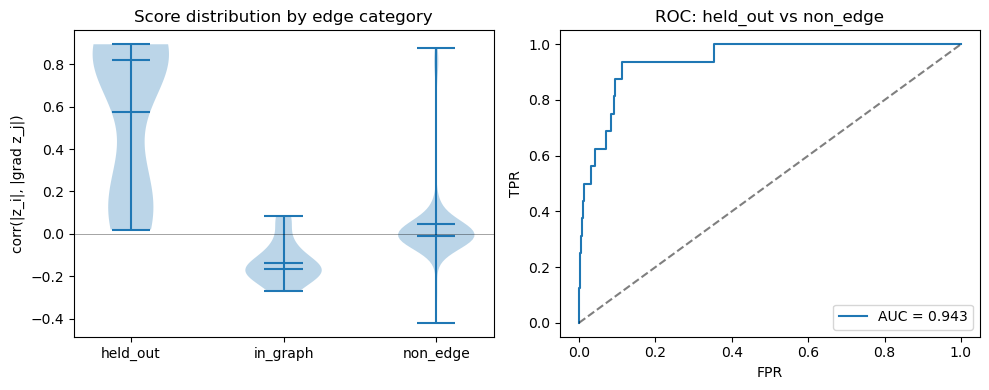

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Violin plot by category
categories = ['held_out', 'in_graph', 'non_edge']
data_plot = [res.loc[res.edge_category == c, 'corr'].dropna().values for c in categories]
parts = axes[0].violinplot(data_plot, showmeans=True, showmedians=True)
axes[0].set_xticks(range(1, len(categories) + 1))
axes[0].set_xticklabels(categories)
axes[0].set_ylabel('corr(|z_i|, |grad z_j|)')
axes[0].set_title('Score distribution by edge category')
axes[0].axhline(0, color='k', lw=0.5, alpha=0.5)

# ROC: held_out (positive) vs non_edge (negative)
pos = res[res.edge_category == 'held_out']['corr'].dropna().values
neg = res[res.edge_category == 'non_edge']['corr'].dropna().values
y_true = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
y_score = np.concatenate([pos, neg])

if len(np.unique(y_true)) == 2:
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
    axes[1].set_xlabel('FPR')
    axes[1].set_ylabel('TPR')
    axes[1].set_title('ROC: held_out vs non_edge')
    axes[1].legend()
else:
    axes[1].text(0.5, 0.5, 'Insufficient classes for ROC', ha='center')

plt.tight_layout()
plt.show()

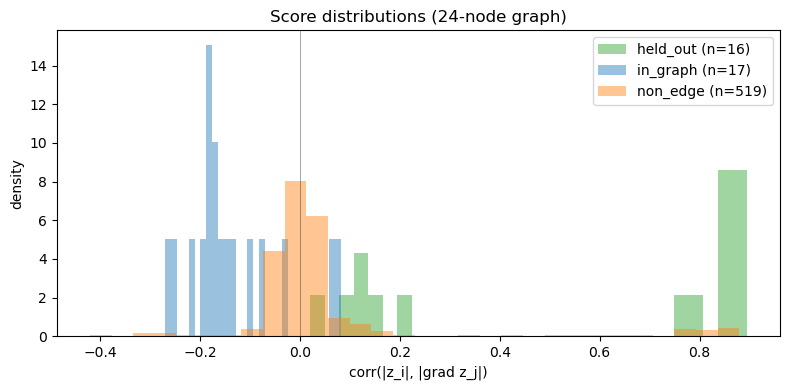

In [43]:
# Score histogram by category
fig, ax = plt.subplots(figsize=(8, 4))
for cat, color in zip(['held_out', 'in_graph', 'non_edge'], ['C2', 'C0', 'C1']):
    vals = res.loc[res.edge_category == cat, 'corr'].dropna().values
    ax.hist(vals, bins=30, alpha=0.45, label=f'{cat} (n={len(vals)})', color=color, density=True)
ax.axvline(0, color='k', lw=0.5, alpha=0.5)
ax.set_xlabel('corr(|z_i|, |grad z_j|)')
ax.set_ylabel('density')
ax.set_title(f'Score distributions ({N_FUNC}-node graph)')
ax.legend()
plt.tight_layout()
plt.show()

## Partial correlation: controlling for kept parents

The plain correlation score is inflated by **transitive paths** and **common upstream causes**: if `i → k → j` already exists in `G_partial`, then `|z_i^{n-1}|` correlates with `|z_k^{n-1}|` (shared upstream drive), which drives `|∇z_j^n|`, so `i → j` looks high even when no direct edge exists.

`MagnitudeEdgeInferer` accumulates one extra statistic during `fit` — the per-layer activation Gram matrix `sum_xx[p]` — which lets us evaluate **partial correlation** at score time, conditioning on the kept parents $S_j = \mathrm{parents}_{G_\mathrm{partial}}(j)$:

$$s_n(i \to j) = \mathrm{pcorr}_b\big(\|z_i^{n-1}\|,\ \|\nabla_{z_j^n}\mathcal{L}\| \;\big|\; \{\|z_k^{n-1}\| : k \in S_j\}\big).$$

Computed in closed form via Schur complement on the streamed sufficient statistics — no extra forward/backward pass. Entries with `i ∈ S_j` (kept edges) are returned as NaN since the source is part of the conditioning set; in-graph edges are therefore correctly absent from the ranked output. Fisher-z p-values use `df = n - 3 - |S_j|`.

In [44]:
res_partial = MEI.evaluate(layer_agg='max', score='partial')
res_partial = res_partial.assign(edge_category=res_partial.apply(edge_category, axis=1))

print('Top 10 partial-correlation pairs:')
cols = ['src_func', 'dst_func', 'corr', 'edge_category', 'has_edge', 'n_cond', 'q_value']
print(res_partial[cols].head(10).to_string())

print('\nCategory summary (partial corr):')
print(res_partial.groupby('edge_category')['corr'].agg(['count', 'mean', 'median', 'std']).to_string())

print('\nPrecision / recall in top-k (partial corr):')
for k in [10, 25, 50, 100]:
    if k > len(res_partial):
        continue
    topk = res_partial.head(k)
    prec = (topk['edge_category'] == 'held_out').mean()
    recall = (topk['edge_category'] == 'held_out').sum() / len(held_out_edges)
    print(f'  top-{k:3d}: precision={prec:.4f}, recall={recall:.4f}')

Top 10 partial-correlation pairs:
  src_func dst_func      corr edge_category  has_edge  n_cond  q_value
0       f2      f14  0.895741      held_out     False       1      0.0
1       f6      f18  0.888803      held_out     False       1      0.0
2       f4      f16  0.881591      held_out     False       1      0.0
3      f15      f16  0.880470      non_edge     False       1      0.0
4       f8      f20  0.870521      held_out     False       1      0.0
5      f17      f18  0.863198      non_edge     False       1      0.0
6      f13      f14  0.863124      non_edge     False       1      0.0
7       f3      f15  0.862425      held_out     False       1      0.0
8      f20      f21  0.860680      non_edge     False       1      0.0
9       f5      f17  0.859305      held_out     False       1      0.0

Category summary (partial corr):
               count      mean   median       std
edge_category                                    
held_out          16  0.579503  0.82903  0.369199
i

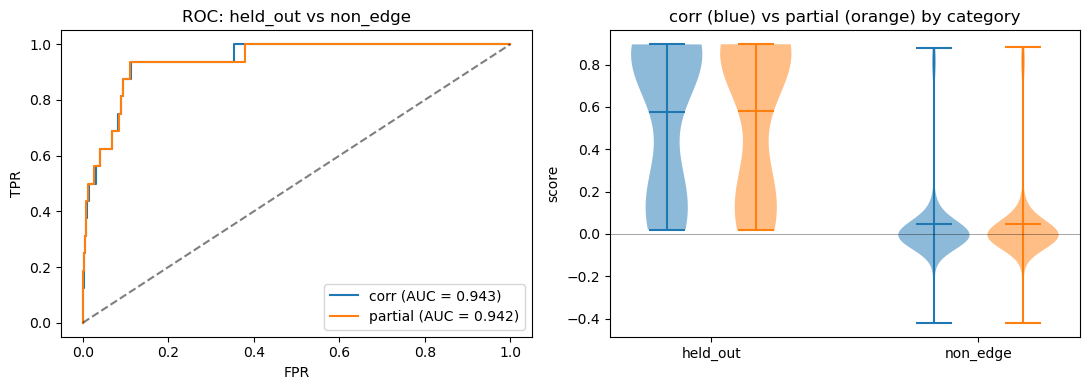

corr    AUC: 0.943
partial AUC: 0.942


In [45]:
def _roc(df, ax, label, color):
    pos = df[df.edge_category == 'held_out']['corr'].dropna().values
    neg = df[df.edge_category == 'non_edge']['corr'].dropna().values
    if len(pos) == 0 or len(neg) == 0:
        return None
    y_true = np.concatenate([np.ones(len(pos)), np.zeros(len(neg))])
    y_score = np.concatenate([pos, neg])
    auc = roc_auc_score(y_true, y_score)
    fpr, tpr, _ = roc_curve(y_true, y_score)
    ax.plot(fpr, tpr, color=color, label=f'{label} (AUC = {auc:.3f})')
    return auc

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

auc_corr = _roc(res, axes[0], 'corr', 'C0')
auc_part = _roc(res_partial, axes[0], 'partial', 'C1')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC: held_out vs non_edge')
axes[0].legend()

cats = ['held_out', 'non_edge']
data_corr = [res.loc[res.edge_category == c, 'corr'].dropna().values for c in cats]
data_part = [res_partial.loc[res_partial.edge_category == c, 'corr'].dropna().values for c in cats]

vp1 = axes[1].violinplot(data_corr, positions=[1, 4], widths=0.8, showmeans=True)
vp2 = axes[1].violinplot(data_part, positions=[2, 5], widths=0.8, showmeans=True)
for b in vp1['bodies']:
    b.set_facecolor('C0'); b.set_alpha(0.5)
for b in vp2['bodies']:
    b.set_facecolor('C1'); b.set_alpha(0.5)
axes[1].set_xticks([1.5, 4.5])
axes[1].set_xticklabels(cats)
axes[1].axhline(0, color='k', lw=0.5, alpha=0.5)
axes[1].set_ylabel('score')
axes[1].set_title('corr (blue) vs partial (orange) by category')

plt.tight_layout()
plt.show()

print(f'corr    AUC: {auc_corr:.3f}')
print(f'partial AUC: {auc_part:.3f}')

## Within-target ranking (MRR, top@k)

Global ROC AUC pools all `(src, dst)` pairs and treats every non-edge as a negative. That can hide a more operational question: **for each target `j` with a missing parent, is the correct source ranked first among all candidates for `j`?**

`MagnitudeEdgeInferer.evaluate_target_ranking` ranks candidate sources per target (descending score) and reports:

- **MRR** (mean reciprocal rank): average of `1 / rank` over held-out edges
- **top@k**: fraction of held-out edges whose true source is in the top `k` for that target

This is stricter than global top-k precision — each target gets its own mini leaderboard.

In [46]:
def print_target_ranking(label, res_df, positive_edges, top_k=(1, 3, 5)):
    detail, summary = MagnitudeEdgeInferer.evaluate_target_ranking(
        res_df, positive_edges=positive_edges, top_k=top_k,
    )
    print(f'=== {label} ===')
    print(f"  MRR: {summary['mrr']:.3f}  (n={int(summary['n_positives'])})")
    for k in top_k:
        print(f"  top@{k}: {summary[f'top@{k}']:.3f}")
    print()
    cols = ['dst_func', 'src_func', 'score', 'rank', 'n_candidates', 'reciprocal_rank'] + [f'top@{k}' for k in top_k]
    print(detail.sort_values(['rank', 'dst_func'])[cols].to_string(index=False))
    print()
    return detail, summary

rank_corr_detail, rank_corr_summary = print_target_ranking('corr', res, held_out_edges)
rank_part_detail, rank_part_summary = print_target_ranking('partial', res_partial, held_out_edges)

=== corr ===
  MRR: 0.636  (n=16)
  top@1: 0.500
  top@3: 0.688
  top@5: 0.750

dst_func src_func    score  rank  n_candidates  reciprocal_rank  top@1  top@3  top@5
     f13       f1 0.802505     1            23         1.000000   True   True   True
     f14       f2 0.895113     1            23         1.000000   True   True   True
     f15       f3 0.853414     1            23         1.000000   True   True   True
     f17       f5 0.848134     1            23         1.000000   True   True   True
     f18       f6 0.886441     1            23         1.000000   True   True   True
     f20       f8 0.870422     1            23         1.000000   True   True   True
     f22      f10 0.850839     1            23         1.000000   True   True   True
     f23      f14 0.200330     1            23         1.000000   True   True   True
     f16       f4 0.876376     2            23         0.500000  False   True   True
     f19       f7 0.843384     2            23         0.500000  False

## Discussion

This notebook implements **Tier 0** from `docs/notes/edge_inference_notes.md` (section 4): a parameter-free score

$$\mathrm{corr}_b\big(\|z_i^{n-1}\|,\; \|\nabla_{z_j^n}\mathcal{L}\|\big)$$

computed post-hoc over a trained GSNN. Scores are aggregated across adjacent layer pairs $(n{-}1, n)$ with `layer_agg='mean'` (or `'max'`). By default, magnitudes are taken from **pre-norm activations** (post-``lin_in``, before the ResBlock norm layer) via `ResBlock._last_pre_norm_activation`, with `retain_grad()` for the backward pass.

### Adjacent-layer pairing

We correlate **activation magnitudes at layer $n{-}1$** with **gradient magnitudes at layer $n$**, not both at the same layer. That matches how GSNN propagates information: forward pass sends activations $z^{n-1} \to z^n$ via message passing; backward pass sends gradients $\nabla z^n \to \nabla z^{n-1}$. A missing edge $i \to j$ should show up when upstream activity at $i$ in layer $n{-}1$ co-moves with downstream loss sensitivity at $j$ in layer $n$.

Per-pair columns in the output are named `corr_a0_g1`, `corr_a1_g2`, … (`a` = activation layer, `g` = gradient layer).

### Gradient absorption (sections 4.5 and 7.1)

At convergence, if edge `i → j` already exists in `G_partial`, the model is locally optimal w.r.t. that input: when `|z_i|` is large, `|∇_{z_j} L|` is *small*. **In-graph edges therefore tend to score near zero or negative**, not high. This is expected and informative — the score highlights *missing-but-useful* edges, not edges the model already uses.

### Partial correlation (`score='partial'`)

The plain Pearson score above suffers from two structural confounds: **transitive paths** (`i → k → j` makes `i → j` look high through `k`) and **common upstream causes** (a shared driver `u → i, u → j` inflates the score of an absent edge). Partial correlation conditioning on the **kept parents** of `j` directly removes the contributions of edges the model already uses. Concretely, for each target `j` we form $S_j = \mathrm{parents}_{G_\mathrm{partial}}(j)$ and compute

$$\mathrm{pcorr}_b\big(\|z_i^{n-1}\|,\ \|\nabla_{z_j^n}\mathcal{L}\| \mid \{\|z_k^{n-1}\| : k \in S_j\}\big)$$

via Schur complement on the streamed `(sum_xx, sum_xy, sum_x2, sum_y2)` sufficient statistics — no extra forward/backward pass. The cost is one extra `(P, N, N)` accumulator and a small per-target solve at evaluation. p-values use Fisher-z with `df = n - 3 - |S_j|`. Kept-edge entries (`i ∈ S_j`) return NaN by construction, so `in_graph` rows drop out of the ranked output rather than competing with held-out candidates.

### Validation

This tutorial follows the synthetic recovery protocol (section 8.1): train on `G_partial ⊊ G*`, score all function-function pairs, and measure whether held-out edges rank above random non-edges (ROC AUC). **Within-target ranking** (`evaluate_target_ranking`) complements global AUC: for each target with a held-out parent, it asks whether the correct source is ranked first among all candidates for that target (MRR, top@k). A random-graph control (section 8.3) is a useful next step.

### Normalization

`MagnitudeEdgeInferer` uses **pre-norm** activations by default (`use_pre_norm=True`): magnitudes are computed after message passing (`lin_in`) but **before** layer / RMS / batch normalization. This preserves cross-sample magnitude variation even when the model is trained with `norm='layer'` or `norm='rms'`.

Post-norm magnitudes (the old behavior, `use_pre_norm=False`) are still misleading for per-node norms — layer and RMS explicitly rescale each node's channels to unit scale, erasing the signal Tier 0 needs. Batch / groupbatch norms applied per channel still leave post-norm geometry somewhat usable, but pre-norm is the safer default for all norm types.

### Next steps

If AUC is at chance, try scoring from an earlier training checkpoint (before full convergence) or escalate to Tier 2 (learned scalar dual encoder). If AUC is strong, Tier 0 may be sufficient as a scalable screen before multivariate verification.